In [1]:
import pandas as pd
import ast
import plotly.graph_objects as go

In [2]:
##Loading data in organized format for Sankey development (changed cometically for ease from ICE_Hotline_merge)

HL_base = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/trafficking_states_master.csv")
HL_base = HL_base.drop(columns=["% of total signals", "% of total cases"])
n_HL_base = len(HL_base) # hotline rows (state-year)

ICE_base = pd.read_csv(
    "C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICERemovalsdata.csv",
    encoding="latin-1",
)

ICE_base = ICE_base.drop(
    columns=["Criminality", "Arresting Agency", "Country of Citizenship",
             "Fiscal Quarter", "Fiscal Month", "Month-Year"]
)

ICE_byyear = ICE_base.groupby(["Area of Responsibility (AOR)", "Fiscal Year"])[
    "Removals"
].sum().reset_index()
n_ICE_byyear = len(ICE_byyear) # ICE AOR-year rows

AOR_merge = pd.read_csv(
    "C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICEEROmanualdatacleancompleted.csv"
)
AOR_merge["office_name"] = (
    AOR_merge["office_name"].str.replace(" Field Office", "", regex=False).str.strip()
)
AOR_merge["area"] = AOR_merge["area"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
areas_exploded = AOR_merge.explode("area").reset_index(drop=True)

In [3]:
# Merging Datasets With Clear Names for Sankey
HL_merged = pd.merge(HL_base, areas_exploded, left_on="State", right_on="area", how="left")
n_HL_no_aor = HL_merged["office_name"].isna().sum() # hotline rows with no AOR match

HL_byAOR = HL_merged.groupby(["office_name", "Year"])[
    ["Signals received", "Cases identified"]
].sum().reset_index()
n_HL_byAOR = len(HL_byAOR) # hotline collapsed to AOR-year

HL_ICE_merged = pd.merge(
    HL_byAOR,
    ICE_byyear,
    left_on=["office_name", "Year"],
    right_on=["Area of Responsibility (AOR)", "Fiscal Year"],
    how="right",
)

# ID for certain rows that do not match
n_after_join = len(HL_ICE_merged)
n_HL_unmatched = HL_ICE_merged["office_name"].isna().sum()  # ICE rows with no hotline match

# 2025 Removals
HL_ICE_merged = HL_ICE_merged[~HL_ICE_merged["Fiscal Year"].isin([2025])]
n_dropped_2025 = n_after_join - len(HL_ICE_merged)
n_after_2025   = len(HL_ICE_merged)

# Dropping Na
n_before_dropna = len(HL_ICE_merged)
HL_ICE_merged   = HL_ICE_merged.dropna()
n_dropped_na    = n_before_dropna - len(HL_ICE_merged)
n_final         = len(HL_ICE_merged)

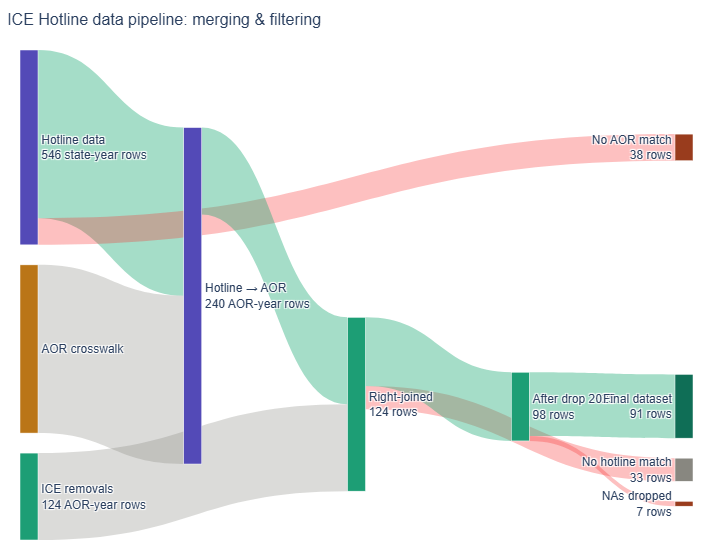

In [4]:
# ── Build Sankey ─────────────────────────────────────────────────────────────
#
# Node index (As reccomended by sources online):
#  0  Hotline data (state-year)
#  1  ICE removals data (AOR-year)
#  2  AOR crosswalk
#  3  Hotline mapped to AOR-year
#  4  Hotline rows: no AOR match
#  5  Right-joined dataset
#  6  ICE rows: no hotline match
#  7  After dropping 2025
#  8  Dropped: 2025 rows
#  9  Final dataset
# 10  Dropped: NAs

##Clairifying types of datasets with new labels
labels = [
    f"Hotline data<br>{n_HL_base} state-year rows",           # 0
    f"ICE removals<br>{n_ICE_byyear} AOR-year rows",          # 1
    f"AOR crosswalk",                                          # 2
    f"Hotline → AOR<br>{n_HL_byAOR} AOR-year rows",           # 3
    f"No AOR match<br>{n_HL_no_aor} rows",                    # 4
    f"Right-joined<br>{n_after_join} rows",                   # 5
    f"No hotline match<br>{n_HL_unmatched} rows",             # 6
    f"After drop 2025<br>{n_after_2025} rows",                # 7
    f"2025 rows<br>{n_dropped_2025} dropped",                 # 8
    f"Final dataset<br>{n_final} rows",                       # 9
    f"NAs dropped<br>{n_dropped_na} rows",                    # 10
]

##Giving color
FLOW    = "rgba(29, 170, 117, 0.4)"   # teal  – rows that survive
DROP    = "rgba(250, 45, 48, 0.3)"    # coral – rows dropped / unmatched
NEUTRAL = "rgba(136, 135, 128, 0.3)"  # gray  – source inputs

##Building sources and targets
sources = [0,  2,  0,  1,  3,  5,  5,  7,  7]
targets = [3,  3,  4,  5,  5,  6,  7,  9, 10]
values  = [
    n_HL_byAOR,       
    n_HL_byAOR,      
    n_HL_no_aor,      
    n_ICE_byyear,    
    n_after_join,    
    n_HL_unmatched, 
    n_after_2025,   
    n_final,        
    n_dropped_na, 
]

##Adding link colors
link_colors = [
    FLOW, NEUTRAL, DROP,
    NEUTRAL, FLOW,
    DROP, FLOW,
    FLOW, DROP,
]

#Giving the nodes matching colors -- this was a MASSIVE pain
node_colors = [
    "#534AB7",  # 0 hotline – purple
    "#1D9E75",  # 1 ICE     – teal
    "#BA7517",  # 2 crosswalk – amber
    "#534AB7",  # 3 hotline AOR – purple
    "#993C1D",  # 4 no AOR match – coral
    "#1D9E75",  # 5 right-joined – teal
    "#888780",  # 6 no hotline match – gray
    "#1D9E75",  # 7 after 2025 – teal
    "#993C1D",  # 8 2025 dropped – coral
    "#0F6E56",  # 9 final – dark teal
    "#993C1D",  # 10 NAs – coral
]

##Actually creating the diagram
Sankey = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=18,
        line=dict(color="white", width=0.5),
        label=labels,
        color=node_colors,
        hovertemplate="%{label}<extra></extra>",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        hovertemplate="Flow: %{value:,} rows<extra></extra>",
    ),
))

Sankey.update_layout(
    title=dict(
        text="ICE Hotline data pipeline: merging & filtering",
        font=dict(size=16),
        x=0.01,
    ),
    font=dict(size=12, family="Arial"),
    margin=dict(l=20, r=20, t=50, b=20),
    height=560,
)

Sankey.show()
